Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from src.audio import load_example_audio, load_audio_file
from src.preprocessing import preprocess_audio
from src.visualization import plot_frequency_spectrum, plot_psd, compute_band_power


Audio

22050 (176400,)
22050 (176400,)
Speech:


Music:


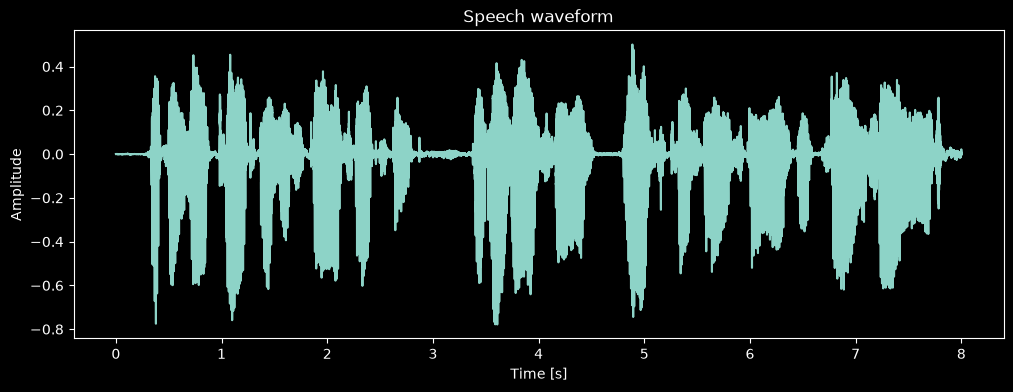

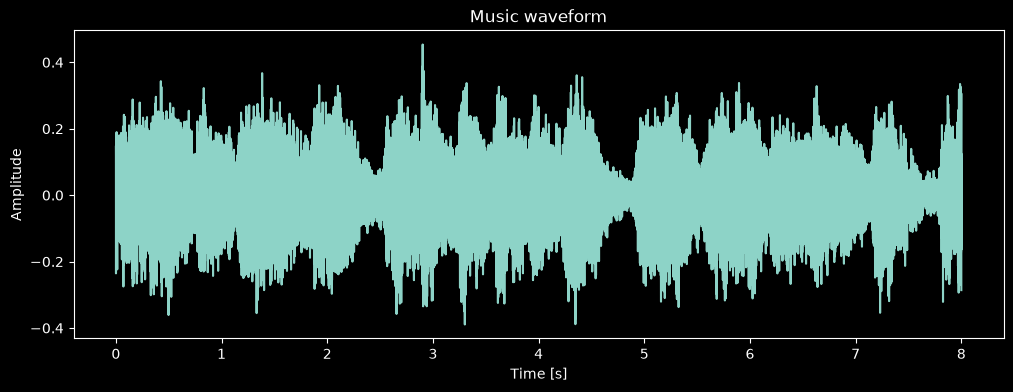

In [2]:
speech, fs_speech = load_example_audio(
    "libri1",
    sr=22050,
    duration=8.0
)

music, fs_music = load_example_audio(
    "brahms",
    sr=22050,
    duration=8.0,
    offset=15.0
)

print(fs_speech, speech.shape)
print(fs_music, music.shape)

print("Speech:")
display(Audio(speech, rate=fs_speech))

print("Music:")
display(Audio(music, rate=fs_music))

time_speech = np.arange(len(speech)) / fs_speech
time_music = np.arange(len(music)) / fs_music

plt.figure(figsize=(12, 4))
plt.plot(time_speech, speech)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Speech waveform")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(time_music, music)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Music waveform")
plt.show()

Preprocessing

In [3]:
speech_processed = preprocess_audio(speech)
music_processed = preprocess_audio(music)

print("Speech")
print("Mean before:", np.mean(speech))
print("Mean after :", np.mean(speech_processed))
print("Peak after :", np.max(np.abs(speech_processed)))

print("\nMusic")
print("Mean before:", np.mean(music))
print("Mean after :", np.mean(music_processed))
print("Peak after :", np.max(np.abs(music_processed)))

from IPython.display import Audio, display

print("Original speech:")
display(Audio(speech, rate=fs_speech))

print("Processed speech:")
display(Audio(speech_processed, rate=fs_speech))

Speech
Mean before: 7.842776e-05
Mean after : 2.7031585e-10
Peak after : 1.0

Music
Mean before: -3.5933706e-05
Mean after : -1.056935e-09
Peak after : 1.0
Original speech:


Processed speech:


Visualization

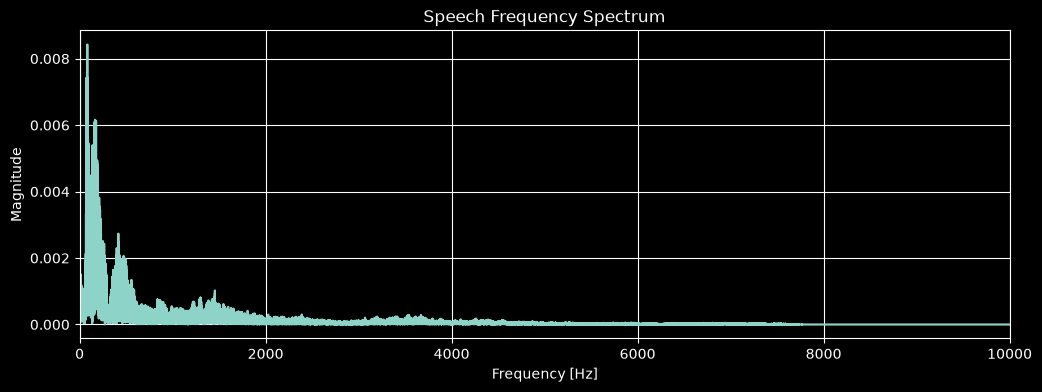

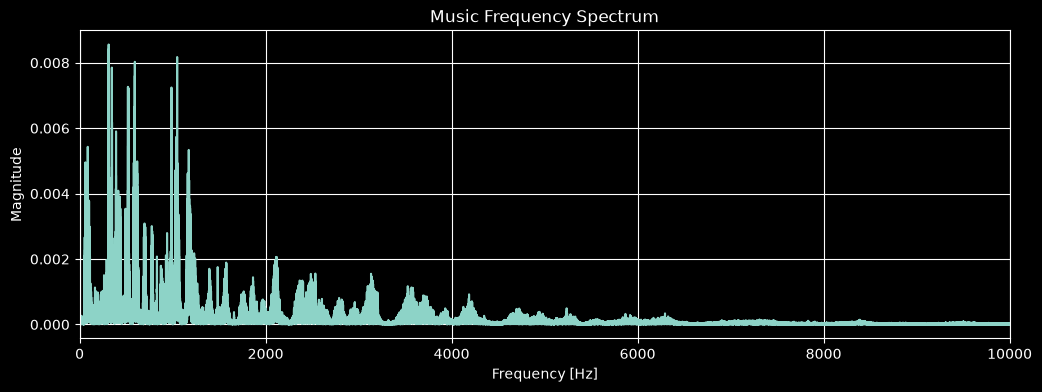

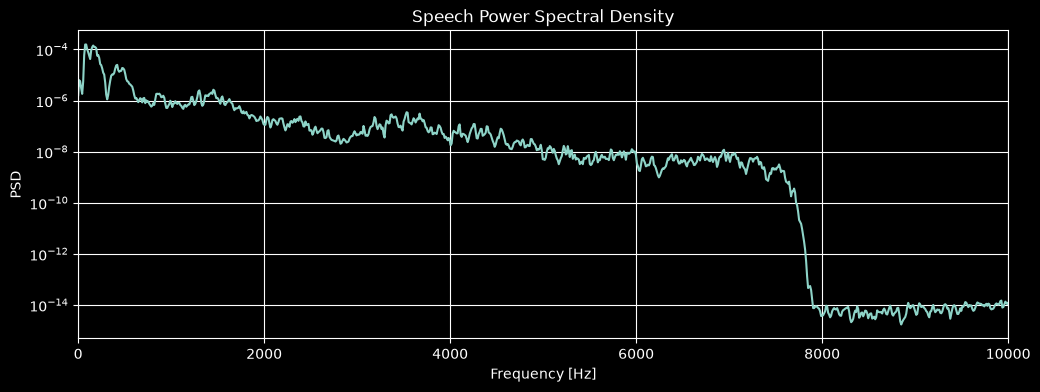

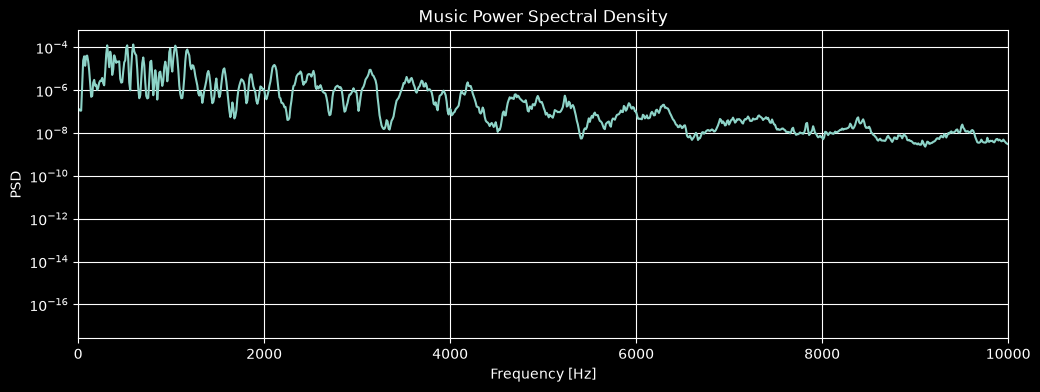

Band [Hz]           Speech [%]   Music [%]
------------------------------------------
200-500                  71.30       19.45
500-1250                 15.66       61.74
1250-3150                10.70       13.75
3150-8000                 2.35        5.06


In [6]:
plot_frequency_spectrum(
    speech_processed,
    fs_speech,
    title="Speech Frequency Spectrum",
    max_freq=10000
)

plot_frequency_spectrum(
    music_processed,
    fs_music,
    title="Music Frequency Spectrum",
    max_freq=10000
)


plot_psd(
    speech_processed,
    fs_speech,
    title="Speech Power Spectral Density"
)

plot_psd(
    music_processed,
    fs_music,
    title="Music Power Spectral Density"
)


band_edges = [200, 500, 1250, 3150, 8000]

speech_band_power = compute_band_power(
    speech_processed,
    fs_speech,
    band_edges
)

music_band_power = compute_band_power(
    music_processed,
    fs_music,
    band_edges
)

print(f"{'Band [Hz]':<18}{'Speech [%]':>12}{'Music [%]':>12}")
print("-" * 42)

for i in range(len(band_edges) - 1):
    band = f"{band_edges[i]}-{band_edges[i+1]}"

    print(
        f"{band:<18}"
        f"{speech_band_power[i]:>12.2f}"
        f"{music_band_power[i]:>12.2f}"
    )